<a href="https://colab.research.google.com/github/YagoGomesDaSilva/Aprendizado-de-Maquina--Nao-Supervisionado/blob/main/Atividade_III_Unidade_Jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigando Agrupamentos Naturais e Gêneros Ocultos através de Características Acústicas

Grupo:
- João Maria de Araújo Nogueira Júnior
- Laura Sabrina de Araújo Menezes
- Maria Amanda de Freitas Morais
- Mateus Freitas de Oliveira
- Yago Gomes da Silva

Base Utilizada:
> [Spotify Tracks Dataset](https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset/data)


### Problemática
Os gêneros musicais tradicionais são historicamente definidos por contextos culturais e comerciais, rótulos que podem não refletir com precisão as reais características físicas e acústicas das composições. Diante da vasta quantidade de dados multimídia contínuos gerados por plataformas de streaming, surge o desafio de entender se essas classificações humanas de fato correspondem a agrupamentos matemáticos e acústicos naturais, ou se a rigidez desses rótulos falha em mapear "gêneros ocultos" — faixas híbridas que transitam fluidamente entre diferentes estilos e compartilham atributos de forma não convencional.

### Objetivo
O intuito dessa analise é investigar se os gêneros musicais (Rock, Jazz, Clássica) formam agrupamentos naturais baseados em suas características acústicas, ou se existem "gêneros ocultos" que misturam essas características.

### Metodologia
Para a realização desta análise, foi utilizado como base o ***Spotify Tracks Dataset***, disponivel no Kaggle. Essa base foi escolhida por conter milhares de músicas com atributos extraídos pelo Spotify (ex: danceability, energy, acousticness, instrumentalness, tempo).


## Preparação dos Dados

### Importando a Base
Inicialmente, a base de dados foi carregada no ambiente Jupyter Notebook via Google Colab, utilizando a linguagem Python. Em seguida, importaram-se as bibliotecas do ecossistema **Scikit-Learn**, essenciais para as etapas de aprendizado de máquina. O bloco de código abaixo executa essas importações.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

print("Insira o Spotify Tracks Dataset:")

uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

    print("\n Dataset Carregado Corretamente:")
    display(df.head(10))


Insira o Spotify Tracks Dataset:


Saving spotify-tracks-dataset.csv to spotify-tracks-dataset (1).csv
User uploaded file "spotify-tracks-dataset (1).csv"

 Dataset Carregado Corretamente:


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


# Análise Exploratória

Número de linhas e colunas do conjunto de dados:

In [13]:
print(df.shape)

(114000, 22)


Contagem, média, desvio padrão, mínimo e máximo das variáveis númericas:

In [14]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Como o objetivo da análise é classificar os diferentes gêneros, é importante identificar quais gêneros estão disponíveis no conjunto de dados:

In [15]:
df['track_genre'].nunique()

114

In [16]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

Ao analisar a distribuição dos gêneros por meio de um histograma, é possível observar que o dataset apresenta uma quantidade equilibrada de registros para cada gênero musical.

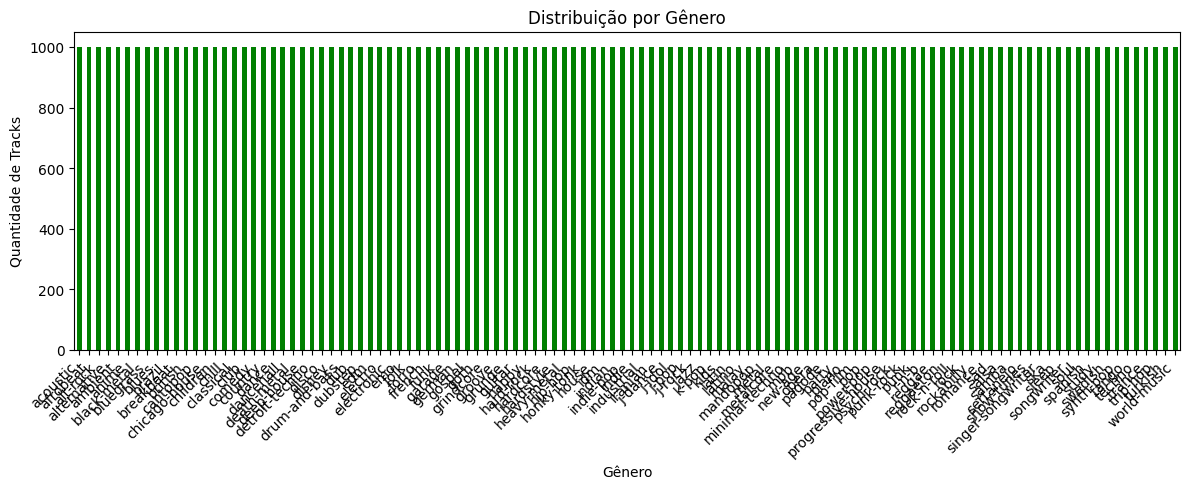

In [17]:
plt.figure(figsize=(12, 5))
df['track_genre'].value_counts().plot(kind='bar', color='green')
plt.title('Distribuição por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

A matriz de correlação permite visualizar, lado a lado, as variáveis do conjunto de dados e analisar o grau de relacionamento entre elas. Para essa análise, foram selecionadas apenas as propriedades numéricas do dataset.

No mapa de calor, tons mais intensos de vermelho indicam correlações positivas mais fortes, enquanto tons de azul representam correlações negativas. Quanto mais intensa a cor, maior a magnitude da correlação observada.

Com base na matriz, é possível identificar algumas relações relevantes, como a forte correlação positiva entre as variáveis *loudness* e *energy*, bem como entre *valence* e *danceability*. Essas correlações sugerem que músicas mais energéticas tendem a apresentar maior volume percebido, enquanto músicas com características mais positivas tendem a ser mais dançantes.


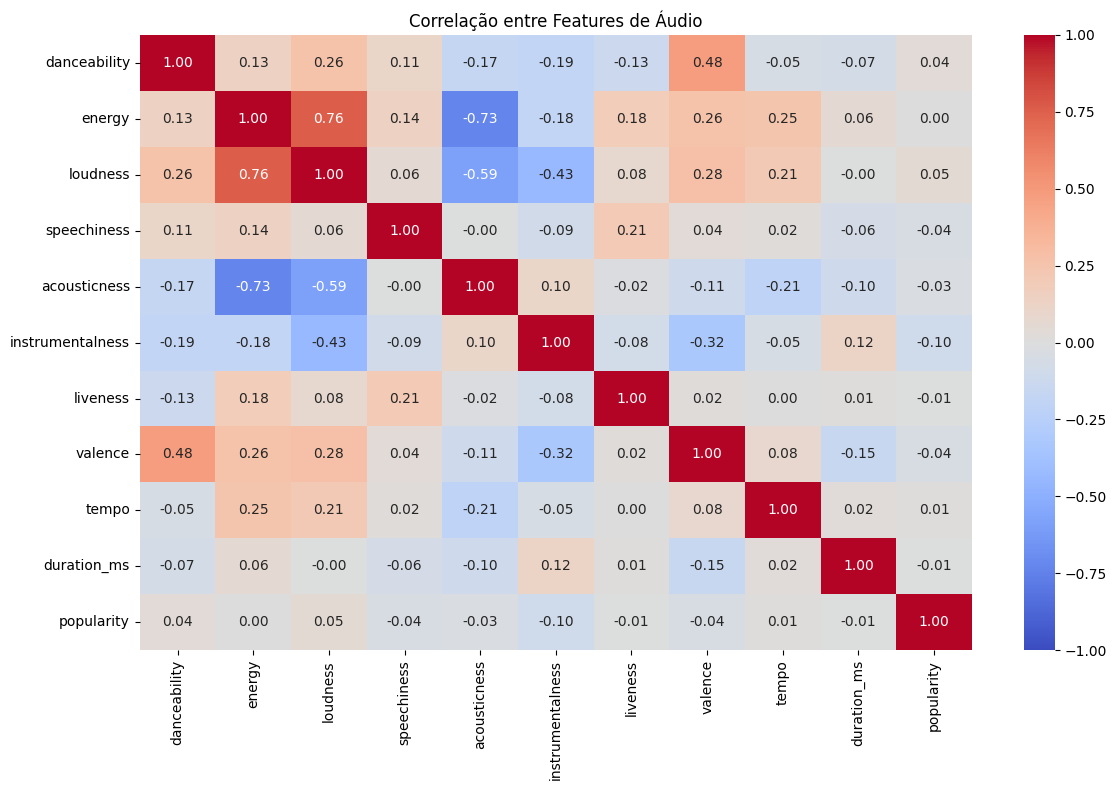

In [18]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_ms', 'popularity']

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.title('Correlação entre Features de Áudio')
plt.tight_layout()
plt.show()

# Redução de Dimensionalidade

Para esta análise, foram aplicadas três técnicas de redução de dimensionalidade, com o objetivo de representar os dados em um espaço de menor dimensão, preservando ao máximo suas características originais e facilitando a visualização dos agrupamentos.

- **PCA (Principal Component Analysis):** técnica linear de redução de dimensionalidade que transforma os atributos originais em novos componentes não correlacionados entre si. Esses componentes são organizados de forma a preservar a maior parte da variância presente nos dados.

- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** técnica não linear baseada em distribuições probabilísticas, amplamente utilizada para visualização de dados em baixa dimensão. Seu principal objetivo é preservar relações de proximidade entre amostras, mantendo pontos semelhantes próximos uns dos outros.

- **UMAP (Uniform Manifold Approximation and Projection):** técnica não linear que busca preservar tanto a estrutura local quanto a estrutura global dos dados. Além de apresentar bom desempenho computacional, é bastante utilizada para visualização e análise de agrupamentos em conjuntos de dados de alta dimensionalidade.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


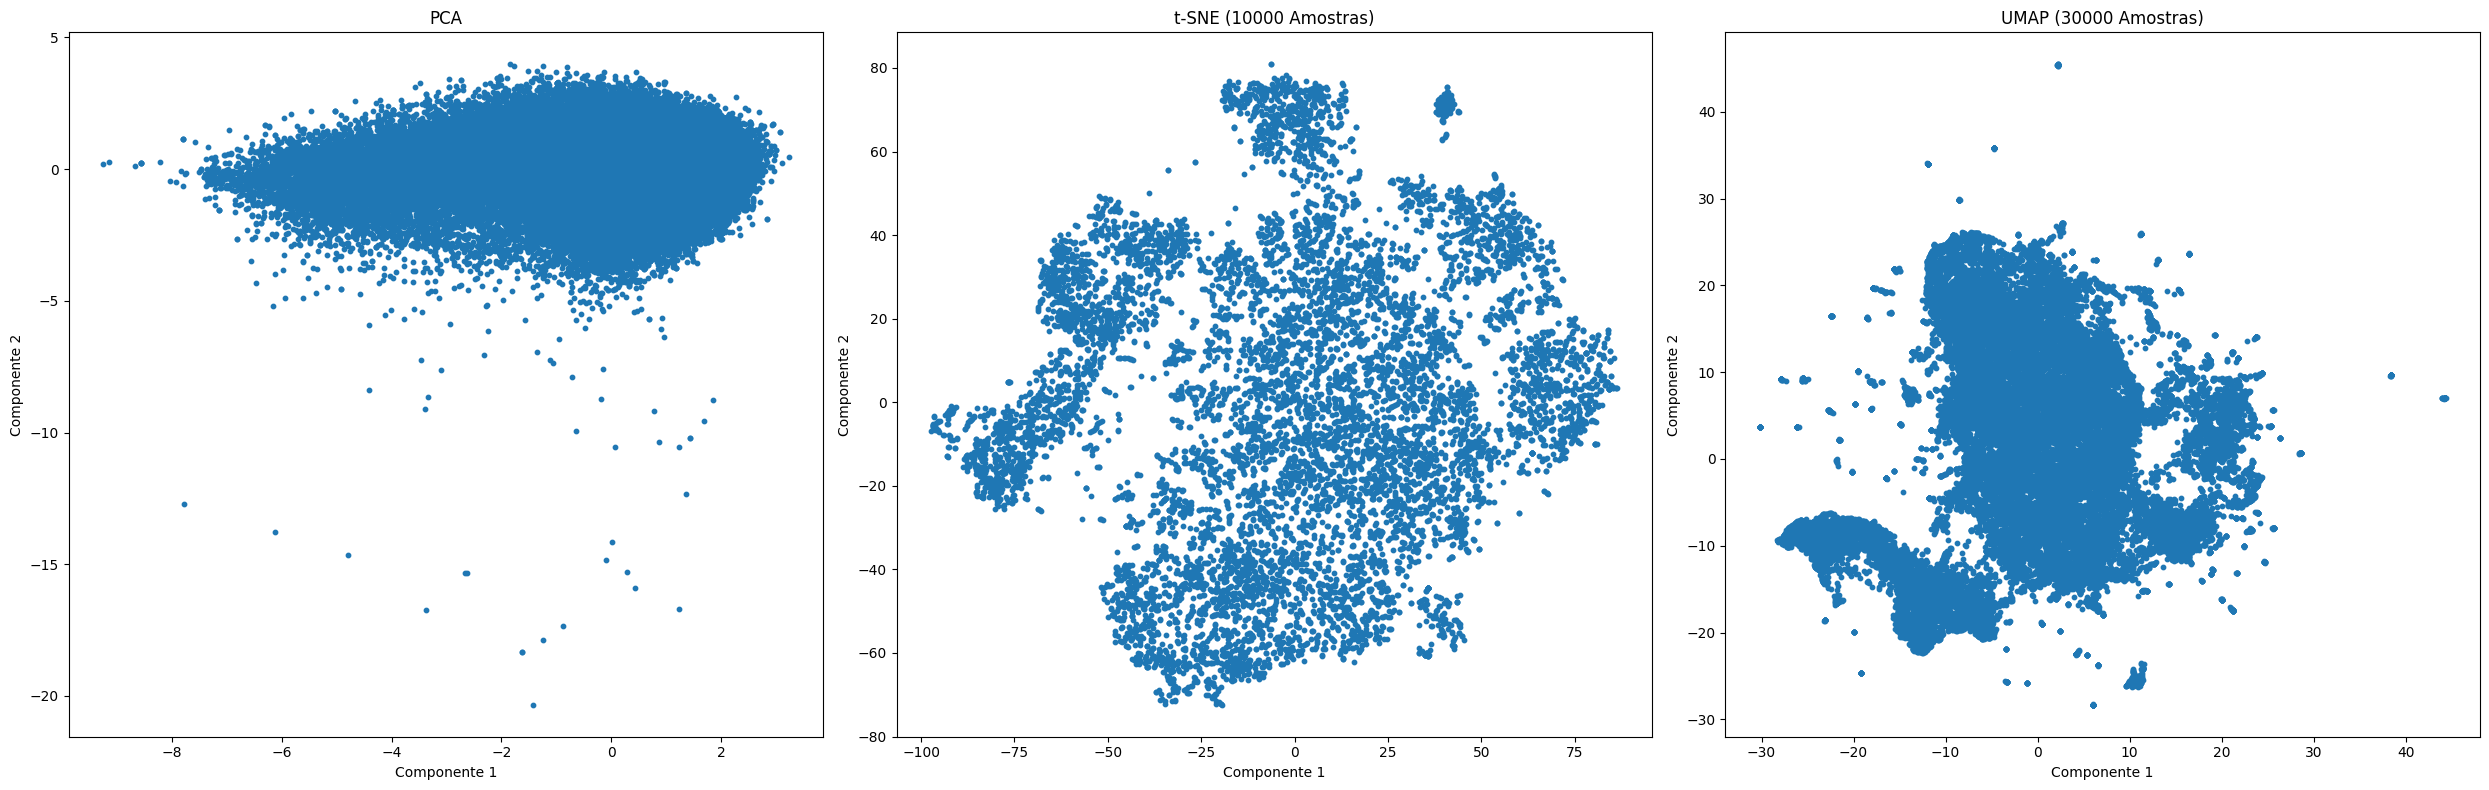

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

parametros_PCA = {'n_components': 2, 'random_state': 42}
parametros_tSNE = {
    'n_components': 2,
    'perplexity': 50,
    'early_exaggeration': 24,
    'learning_rate': 500,
    'init': 'pca',
    'random_state': 42
}
parametros_UMAP = {'n_components': 2,'n_neighbors': 30,'min_dist': 0.0,'spread': 5.0, 'metric': 'euclidean','random_state': 42}

# Dataset Apenas com Features Relevantes para a Analise
X = df[audio_features]

# Normalização dos atributos
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

def plot_2D_graph(data, title, ax, labels=None):
    if labels is None:
        ax.scatter(data[:, 0], data[:, 1], s=10)
    else:
        scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=10)
        plt.colorbar(scatter, ax=ax, label='Cluster')

    ax.set_title(title)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')


fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# PCA
pca_df = PCA(**parametros_PCA).fit_transform(X_scaled)
plot_2D_graph(pca_df, 'PCA', axes[0])

# t-SNE
sample_size = 10000
X_tsne_sample = (
    X_scaled.sample(n=sample_size, random_state=42)
    if len(X_scaled) > sample_size
    else X_scaled
)
tsne_df = TSNE(**parametros_tSNE).fit_transform(X_tsne_sample)
plot_2D_graph(tsne_df, 't-SNE (10000 Amostras)', axes[1])

# UMAP
sample_size = 30000
X_umap_sample = (
    X_scaled.sample(n=sample_size, random_state=42)
    if len(X_scaled) > sample_size
    else X_scaled
)
umap_df = umap.UMAP(**parametros_UMAP).fit_transform(X_umap_sample)
plot_2D_graph(umap_df, f'UMAP ({sample_size} Amostras)', axes[2])

plt.tight_layout()
plt.show()

Optou-se pelo uso do **t-SNE** para a etapa clusterização, uma vez que a técnica apresentou a melhor performance na formação dos agrupamentos. Os resultados revelaram uma definição de clusters mais nítida e intuitiva, facilitando a interpretação da variabilidade dos dados. Vale pontuar que a escolha por este algoritmo priorizou a qualidade da segmentação em detrimento do custo computacional, que é mais elevado do que o apresentado pelas demais abordagens testadas.

# Clusterização
Com os dados projetados no espaço bidimensional atravez do **T-SNE**, se torna possivel observar a formação de agrupamentos naturais de músicas com características sonoras semelhantes. A proxima fase da analise é aplicar um algoritmo de clusterização como o **DBSCAN** sobre a projeção para identificar e rotular esses agrupamentos, isolando pontos muito dispersos como ruído.

Para reduzir o ruído o máximo possível e dado o critério acadêmico desta análise, **qualquer grupo que represente menos de 1% da base de dados original será removido por ser insignificante**. Em seguida, extrairemos o perfil médio dos atributos de áudio, destacando as principais características de cada agrupamento, o que nos permitirá inferir quais gêneros ou estilos musicais cada um deles representa.


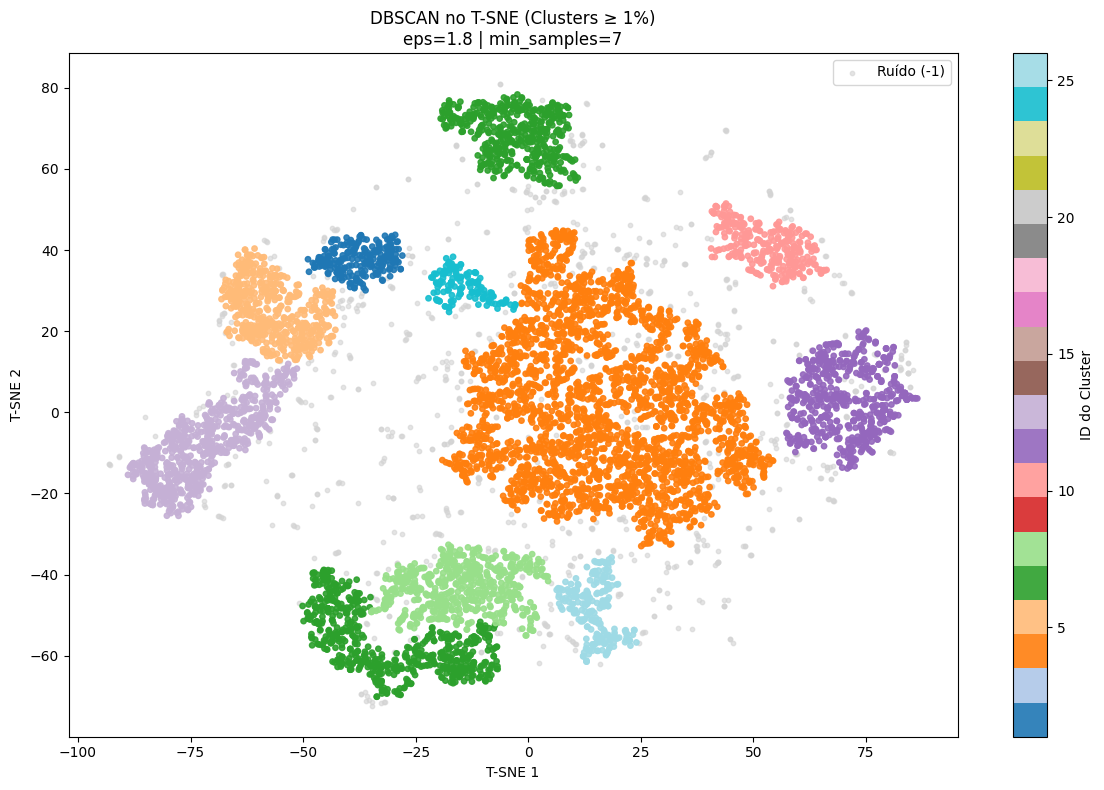


--- Resumo da Limpeza ---
Total de amostras originais: 10000
Total de amostras após limpeza: 7772
Porcentagem total retida (incluindo ruído): 77.72%

--- Distribuição dos Clusters (Após Limpeza) ---


,Cluster,Quantidade,% (Base Limpa),% (Base Original),% Acumulada (Base Original)
0,-1,808,10.40,8.08,8.08
1,1,232,2.99,2.32,10.40
2,4,2670,34.35,26.70,37.10
3,5,508,6.54,5.08,42.18
4,6,487,6.27,4.87,47.05
5,7,621,7.99,6.21,53.26
6,8,549,7.06,5.49,58.75
7,10,294,3.78,2.94,61.69
8,12,596,7.67,5.96,67.65
9,13,648,8.34,6.48,74.13



--- Média dos Atributos de Áudio por Cluster ---


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
1,-1.432502,1.030447,0.412493,0.144086,-0.891123,1.908108,0.027288,-1.116256,0.535244,-0.020975,-0.680098
4,0.049026,0.560106,0.517384,-0.198617,-0.686415,-0.450285,-0.197753,0.190966,0.301416,-0.075980,0.591009
5,0.655084,0.505748,-0.003487,-0.262013,-0.789343,2.018998,-0.398501,-0.446840,0.074716,0.834697,-0.101684
6,-0.231695,0.304713,0.214206,-0.122810,0.134622,-0.469517,2.956308,0.183574,-0.105171,0.095248,0.273126
7,-0.522949,-1.448721,-0.837037,-0.390336,1.573470,-0.447458,-0.308758,-0.332460,-0.875979,-0.335651,-0.464656
8,-0.220419,-1.089198,-0.368653,-0.406563,1.230289,-0.470705,-0.406310,-0.644163,0.185055,-0.030049,0.640896
10,0.856973,-0.002468,0.223712,2.155924,-0.217596,-0.484959,-0.310639,0.416661,-0.101606,-0.325610,0.144696
12,0.764388,0.566390,0.598745,-0.159622,-0.678596,-0.478436,-0.206804,0.700305,-0.382421,-0.203630,-1.448436
13,-0.673848,-1.526914,-1.914353,-0.303437,1.465887,2.266406,-0.436395,-0.678944,-0.410469,-0.335784,-0.189196


In [20]:
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DBSCAN
parametros_DBSCAN = {'eps': 1.8, 'min_samples': 7}
dbscan = DBSCAN(**parametros_DBSCAN)
clusters = dbscan.fit_predict(tsne_df)

X_tsne_sample = X_tsne_sample.copy()
X_tsne_sample['cluster'] = clusters

# Filtragem de Ruido Clusters (clusters que representam menos de 1% do dataset são tratados como ruido)
total_amostras = len(X_tsne_sample)
contagem = X_tsne_sample['cluster'].value_counts().reset_index()
contagem.columns = ['cluster', 'quantidade']
contagem['percentual'] = (contagem['quantidade'] / total_amostras) * 100

# Remoção de Ruido do propio DBSCAN
clusters_remover = contagem[(contagem['percentual'] < 1) & (contagem['cluster'] != -1)]['cluster'].tolist()

# Aplica do Filtro para remover o ruido
mascara_validos = ~X_tsne_sample['cluster'].isin(clusters_remover)
X_filtrado = X_tsne_sample[mascara_validos].copy()
tsne_filtrado = tsne_df[mascara_validos]
clusters_filtrados = X_filtrado['cluster'].values

# Plot Config.
plt.figure(figsize=(12, 8))

mascara_ruido = (clusters_filtrados == -1)
ruido = tsne_filtrado[mascara_ruido]
dados_clusters = tsne_filtrado[~mascara_ruido]
labels_clusters = clusters_filtrados[~mascara_ruido]

# Plot do ruído separado
plt.scatter(ruido[:, 0], ruido[:, 1], color='lightgrey', label='Ruído (-1)', s=10, alpha=0.6)
scatter = plt.scatter(dados_clusters[:, 0], dados_clusters[:, 1],
                      c=labels_clusters, cmap='tab20', s=15, alpha=0.9)

plt.colorbar(scatter, label='ID do Cluster')
plt.title(f"DBSCAN no T-SNE (Clusters ≥ 1%)\neps={parametros_DBSCAN['eps']} | min_samples={parametros_DBSCAN['min_samples']}")
plt.xlabel('T-SNE 1')
plt.ylabel('T-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()

# Tabela com os clusters encontrados
total_retido_pct = round((len(X_filtrado) / total_amostras) * 100, 2)
print(f"\n--- Resumo da Limpeza ---")
print(f"Total de amostras originais: {total_amostras}")
print(f"Total de amostras após limpeza: {len(X_filtrado)}")
print(f"Porcentagem total retida (incluindo ruído): {total_retido_pct}%\n")

distribuicao = X_filtrado['cluster'].value_counts().reset_index()
distribuicao.columns = ['Cluster', 'Quantidade']

distribuicao['% (Base Limpa)'] = round((distribuicao['Quantidade'] / len(X_filtrado)) * 100, 2)
distribuicao['% (Base Original)'] = round((distribuicao['Quantidade'] / total_amostras) * 100, 2)

# sort by
distribuicao = distribuicao.sort_values(by='Cluster').reset_index(drop=True)
distribuicao['% Acumulada (Base Original)'] = distribuicao['% (Base Original)'].cumsum()

# Tabela das medias dos atributos de cada cluster encontrado
perfil_clusters = X_filtrado[X_filtrado['cluster'] != -1].groupby('cluster').mean()

print("--- Distribuição dos Clusters (Após Limpeza) ---")
display(distribuicao)

print("\n--- Média dos Atributos de Áudio por Cluster ---")
display(perfil_clusters)

## Inferência

Para inferirmos com maior acurácia qual estilo ou gênero musical cada agrupamento representa, primeiramente precisamos compreender melhor o comportamento e a distribuição dos pontos de dados que o compõem. Para isso, nesta etapa foram separados, para cada cluster, os dois atributos com maior desvio padrão positivo em relação à média (atributos pelos quais as músicas do agrupamento são mais bem representadas) e os dois atributos com maior desvio padrão negativo (atributos menos representativos das músicas do agrupamento). Com essas informações em mãos, um especialista seria capaz de rotular os agrupamentos com maior facilidade.

Os resultados da tabela que descreve com maior precisão cada cluster podem ser observados a seguir, seguidos das inferências realizadas para cada agrupamento.


In [23]:
import pandas as pd

linhas_tabela = []

#descarta cluster de ruido
contagem_clusters = X_filtrado[X_filtrado['cluster'] != -1]['cluster'].value_counts()

for cluster_id, row in perfil_clusters.iterrows():

    qtd_pontos = contagem_clusters.get(cluster_id, 0)

    # order by
    ordenado = row.sort_values()

    # menores medias
    menor_1_nome, menor_1_val = ordenado.index[0], ordenado.iloc[0]
    menor_2_nome, menor_2_val = ordenado.index[1], ordenado.iloc[1]

    # maiores medias
    maior_1_nome, maior_1_val = ordenado.index[-1], ordenado.iloc[-1]
    maior_2_nome, maior_2_val = ordenado.index[-2], ordenado.iloc[-2]

    str_maiores = f"{maior_1_nome} [ {maior_1_val:.4f} ] , {maior_2_nome} [ {maior_2_val:.4f} ]"
    str_menores = f"{menor_1_nome} [ {menor_1_val:.4f} ] , {menor_2_nome} [ {menor_2_val:.4f} ]"

    linhas_tabela.append([cluster_id, qtd_pontos, str_maiores, str_menores])

# print
tabela_extremos = pd.DataFrame(
    linhas_tabela,
    columns=['Cluster', 'Quantidade', 'Maiores Atributos', 'Menores Atributos']
)

tabela_extremos.set_index('Cluster', inplace=True)
# justify
tabela_formatada = tabela_extremos.style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

display(tabela_formatada)

,Quantidade,Maiores Atributos,Menores Atributos
Cluster,,,
1,232,"instrumentalness [ 1.9081 ] , energy [ 1.0304 ]","danceability [ -1.4325 ] , valence [ -1.1163 ]"
4,2670,"popularity [ 0.5910 ] , energy [ 0.5601 ]","acousticness [ -0.6864 ] , instrumentalness [ -0.4503 ]"
5,508,"instrumentalness [ 2.0190 ] , duration_ms [ 0.8347 ]","acousticness [ -0.7893 ] , valence [ -0.4468 ]"
6,487,"liveness [ 2.9563 ] , energy [ 0.3047 ]","instrumentalness [ -0.4695 ] , danceability [ -0.2317 ]"
7,621,"acousticness [ 1.5735 ] , liveness [ -0.3088 ]","energy [ -1.4487 ] , tempo [ -0.8760 ]"
8,549,"acousticness [ 1.2303 ] , popularity [ 0.6409 ]","energy [ -1.0892 ] , valence [ -0.6442 ]"
10,294,"speechiness [ 2.1559 ] , danceability [ 0.8570 ]","instrumentalness [ -0.4850 ] , duration_ms [ -0.3256 ]"
12,596,"danceability [ 0.7644 ] , valence [ 0.7003 ]","popularity [ -1.4484 ] , acousticness [ -0.6786 ]"
13,648,"instrumentalness [ 2.2664 ] , acousticness [ 1.4659 ]","loudness [ -1.9144 ] , energy [ -1.5269 ]"


In [33]:
import plotly.graph_objects as go
import pandas as pd

# Rótulos inferidos
rotulos_dict = {
    1: 'Rock',
    4: 'Pop',
    5: 'Eletronica/Post-Rock',
    6: 'Sertanejo',
    7: 'Folk',
    8: 'Indie rock',
    10: 'Rap / HipHop',
    12: 'Indie pop',
    13: 'Musica Clássica',
    24: 'Metal',
    26: 'MPB'
}

df_plot = pd.DataFrame({
    'T-SNE 1': tsne_filtrado[:, 0],
    'T-SNE 2': tsne_filtrado[:, 1],
    'Cluster': clusters_filtrados
})
df_plot['Gênero'] = df_plot['Cluster'].map(rotulos_dict).fillna('Desconhecido')

fig = go.Figure()

# Plot
clusters_validos = sorted([c for c in df_plot['Cluster'].unique() if c != -1])

for c in clusters_validos:
    mascara = df_plot['Cluster'] == c
    nome_genero = rotulos_dict.get(c, 'Desconhecido')

    fig.add_trace(go.Scatter(
        x=df_plot.loc[mascara, 'T-SNE 1'],
        y=df_plot.loc[mascara, 'T-SNE 2'],
        mode='markers',
        marker=dict(size=6, opacity=0.9),
        name=f'{c} - {nome_genero}',
        hovertext=[f'Cluster: {c}<br>Gênero: {nome_genero}'] * mascara.sum(),
        hoverinfo='text'
    ))

fig.update_layout(
    title=f"Resultados da Inferência do Rotulos <br><sup>DBSCAN (eps={parametros_DBSCAN['eps']} | min_samples={parametros_DBSCAN['min_samples']})</sup>",
    xaxis_title='T-SNE 1',
    yaxis_title='T-SNE 2',
    legend_title='Rótulos',
    width=1000,
    height=800,
    template='plotly_white'
)

fig.show()